# LangGraph Chatbot

This code block installs the required libraries.

In [1]:
%%capture
!pip install --quiet -U langchain_aws langchain_core langgraph langgraph-prebuilt boto3
!pip install --upgrade python-dotenv

This code block imports the necessary libraries.

In [2]:
import os
import boto3
import json
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage
from langchain_aws import ChatBedrock
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import Image, display

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


This code block sets up the environment variables.

In [3]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv('AWS_ACCESS_KEY_ID')
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv('AWS_SECRET_ACCESS_KEY')
os.environ["AWS_DEFAULT_REGION"] =os.getenv('AWS_DEFAULT_REGION')


In [4]:
os.environ["LANGSMITH_API_KEY"] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGSMITH_ENDPOINT"]="https://api.smith.langchain.com"
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "tutorial"

In [5]:
from typing import TypedDict, List
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: List[BaseMessage]
    # Add other relevant state variables if needed

### **AWS Bedrock Agent as a Tool**

In [6]:
import json
import uuid
import boto3
from langchain_core.tools import tool

@tool
def it_support_agent_invoke_bedrock_agent_node(state):
    """Invoke the IT Support Agent."""
    messages = state.get("messages", [])
    user_messages = [m for m in messages if getattr(m, "type", "") == "human" or getattr(m, "role", "") == "user"]
    if not user_messages:
        raise ValueError("No user message found in state.")
    
    input_text = user_messages[-1].content
    session_id = "it-support-session-" + str(uuid.uuid4())

    client = boto3.client("bedrock-agent-runtime", region_name="us-east-1")

    print(f"[INFO] Invoking Bedrock Agent: session_id={session_id} | input_text={input_text}")

    response_stream = client.invoke_agent(
        agentId="3YJXHZXQNK",
        agentAliasId="UGSDLBDDAE",
        sessionId=session_id,
        inputText=input_text
    )

    # Collect the text output from the event stream
    final_output = ""
    for event in response_stream["completion"]:
        if "chunk" in event:
            chunk = event["chunk"]["bytes"].decode("utf-8")
            final_output += chunk
        elif "trace" in event:
            print("[TRACE EVENT]", event["trace"])
        elif "exception" in event:
            print("[EXCEPTION]", event["exception"])

    print("[INFO] Agent response collected.")
    return {"response": final_output}


This code block defines the list of tools to be used by the chatbot.

In [7]:
tools = [it_support_agent_invoke_bedrock_agent_node]

# Define LangGraph state

This code block defines the LangGraph state and the chatbot node.

In [8]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)
llm = ChatBedrock(model_id="amazon.nova-lite-v1:0", temperature=0)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"]) ]}

graph_builder.add_node("chatbot", chatbot)

# Define tool execution node

This code block defines the tool execution node.

This code block defines the routing logic for the LangGraph.

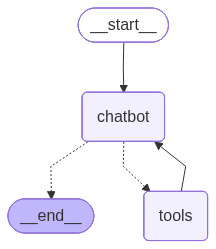

In [ ]:


graph_builder.add_conditional_edges("chatbot", tools_call)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

# Optional visualization
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

This code block contains the interaction loop to ask questions to the chatbot.

In [13]:
# Example prompt
user_prompt = "I’m facing frequent Wi-Fi disconnections. Please use the IT Support Agent to identify the cause and suggest fixes."
user_prompt1 = "Please use the IT Support Agent to explain who Elon Musk is."

# Send the prompt to the graph
for event in graph.stream({"messages": [{"role": "user", "content": user_prompt1}]}):
    for value in event.values():
        if "messages" in value and value["messages"]:
            print("Assistant:", value["messages"][-1].content)


Assistant: [{'type': 'text', 'text': "<thinking> The User has asked for an explanation about Elon Musk. I can't provide this information directly, but I can use the IT Support Agent to find out more information about Elon Musk. </thinking>\n"}, {'type': 'tool_use', 'name': 'it_support_agent_invoke_bedrock_agent_node', 'input': {'state': {'query': 'Who is Elon Musk?'}}, 'id': 'tooluse_CSnbD-_zS3-YssppaQF7cA'}]
[INFO] Tool Invoked: it_support_agent_invoke_bedrock_agent_node | args: {'state': {'messages': [HumanMessage(content='Please use the IT Support Agent to explain who Elon Musk is.', additional_kwargs={}, response_metadata={}, id='4a2f1b17-bb66-4574-bd81-be5fbe7918d2'), AIMessage(content=[{'type': 'text', 'text': "<thinking> The User has asked for an explanation about Elon Musk. I can't provide this information directly, but I can use the IT Support Agent to find out more information about Elon Musk. </thinking>\n"}, {'type': 'tool_use', 'name': 'it_support_agent_invoke_bedrock_agen

These are example prompts to use with the chatbot.

In [12]:
# i need a IT support to trouble shoot network issues